# Итоговое задание: прогноз конечной температуры стали в дуговой сталеплавильной печи

Введение

Так как по основной своей работе я разработчик MES системы для металлургических предприятий в качестве датасета я выбрал близкую мне тему - работу дуговой сталеплавильной печи / electric arc furnace ( ДСП / EAF). 

Сылка на исходный датасет:

 https://www.kaggle.com/datasets/yuriykatser/industrial-data-from-the-arc-furnace/data

В данном репозитории представлены несколько файлов, я решил подробно проанализировать все, чтобы понять что мне может пригодится в решении проблематики по задаче, и отразил в рамках EDA информацию по всем файлам. Но в дальнейшей работе в рамках задач 2-4 будут использованы не все.

* Выбранная тема / проблематика: **прогноз конечной температуры стали перед выпуском плавки**


## Задача №1. Статистические методы прогнозирования

### Импорты и настройки

In [147]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Date Parser
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style('white')
sns.set(rc={'figure.figsize': (11, 4)})
import warnings

warnings.filterwarnings('ignore', category=FutureWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

from pathlib import Path

PROJECT_DIR = Path.cwd()

## Загрузка данных в Pandas

Данные лежат в каталоге `EAF_Dataset`. В датасете несколько таблиц: часть описывает отдельные измерения температуры и химического состава, часть фиксирует технологические события внутри плавки: работу трансформатора, подачу кислорода/газа, инжекцию углерода, загрузку шихты и добавки.

Ниже приведено назначение файлов датасета и их роль в текущей задаче.

* **Dataset_description.txt** - описание датасета
* **eaf_temp.csv** -измерения температуры стали (TEMP) и степени окисления (VALO2_PPM) по плавкам, это основной файл - из него формирую целевую переменную
* **eaf_transformer.csv** - режимы работы трансформатора: ступень **TAP**, время начала, длительность, потребление (**MW**), источник признаков, связанных с электрической энергией и режимом нагрева 
* **eaf_gaslance_mat.csv** -накопленные объемы и потоки кислорода и газа: **O2_AMOUNT**, **GAS_AMOUNT**, **O2_FLOW**, **GAS_FLOW** - источник признаков химико-теплового воздействия на плавку.
* **inj_mat.csv** - расход и поток инжектируемого углерода - источник признаков, связанных с вспениванием шлака, углеродом и тепловым режимом
* **basket_charged.csv** - загрузка шихты из корзины: материал, код материала, масса, время загрузки - источник признаков по начальной массе и составу загруженных материалов.
* **eaf_added_materials.csv** - дополнительные материалы, добавленные в EAF во время плавки - источник признаков по корректировкам процесса до целевого измерения температуры
* **ladle_tapping.csv** - леггирующие материалы, добавленные при выпуске стали в печь-ковш (Ladle Furnace), важен для металлургического контекста, но в текущей постановке не используется как признак, чтобы не добавить информацию после решения о выпуске.
* **lf_initial_chemical_measurements.csv** - начальный химический состав на установке печь-ковш после ДСП
* **lf_added_materials.csv** - добавки на установке печь-ковш до первоначальных проб по химии - относится к следующей стадии процесса, в текущую задачу по ДСП не включается
* **eaf_final_chemical_measurements.csv** - химический состав стали после ДСП - альтернативная целевая таблица для задачи прогноза химсостава; В моей работе я выбрал другую задачу, так что в дальнейшем файл не будет использоваться.

* **ferro.csv** справочник ферросплавов - материалов и химических элементов в них, также не будет использоваться

В рамках EDA я рассмотред  eaf_temp.csv для целевого ряда и несколько доп. файлов для признаков: eaf_transformer.csv, eaf_gaslance_mat.csv, inj_mat.csv, basket_charged.csv, eaf_added_materials.csv.

In [105]:
DATA_DIR = PROJECT_DIR / 'EAF_Dataset'
PREPARED_DIR = PROJECT_DIR / 'prepared_data'

assert DATA_DIR.exists(), f'Каталог с датасетом не найден: {DATA_DIR}'

csv_files = sorted(DATA_DIR.glob('*.csv'))
file_table = pd.DataFrame({
    'file': [p.name for p in csv_files],
    'size_mb': [p.stat().st_size / 1024**2 for p in csv_files],
}).sort_values('file')

В описании датасета указаны три основные прикладные проблемы:

* прогноз температуры стали;
* прогноз степени окисления стали;
* прогноз химического состава стали после выпуска из электродуговой печи.

В рамках текущего проекта я выбрал первую проблему, потому что таблица eaf_temp.csv имеет максимальное покрытие по плавкам и хорошо подходит под сравнение статистических, ML и DL методов.

#### Обзор таблиц

In [ ]:
TIME_COLUMNS = ['DATETIME', 'STARTTIME', 'REVTIME', 'FILTER_KEY_DATE']


def profile_csv(path, chunksize=250_000):
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    usecols = [c for c in cols if c == 'HEATID' or c in TIME_COLUMNS]

    rows = 0
    heats = set()
    time_min = {}
    time_max = {}

    for chunk in pd.read_csv(path, usecols=usecols if usecols else None, chunksize=chunksize):
        rows += len(chunk)

        if 'HEATID' in chunk.columns:
            heats.update(chunk['HEATID'].dropna().astype(str).unique())

        for col in [c for c in TIME_COLUMNS if c in chunk.columns]:
            dt = pd.to_datetime(
                chunk[col].astype(str).str.replace(',', '.', regex=False),
                errors='coerce' )

            if dt.notna().any():
                time_min[col] = dt.min() if col not in time_min else min(time_min[col], dt.min())
                time_max[col] = dt.max() if col not in time_max else max(time_max[col], dt.max())

    return {
        'file': path.name,
        'rows': rows,
        'columns': len(cols),
        'heats': len(heats),
        'time_columns': ', '.join(time_min.keys()),
        'time_min': min(time_min.values()) if time_min else pd.NaT,
        'time_max': max(time_max.values()) if time_max else pd.NaT,
    }


profile = pd.DataFrame([profile_csv(path) for path in csv_files if path.suffix == '.csv'])
profile.sort_values('rows', ascending=False)

,file,rows,columns,heats,time_columns,time_min,time_max
3,eaf_gaslance_mat.csv,5748194,6,20827,REVTIME,2015-01-01 00:50:37.617,2018-07-29 09:20:27.743
7,inj_mat.csv,4011646,4,20827,REVTIME,2015-01-01 00:50:37.586,2018-07-29 09:20:27.712
9,lf_added_materials.csv,302445,5,20374,FILTER_KEY_DATE,2015-01-01 02:46:00.000,2018-07-30 10:20:00.000
5,eaf_transformer.csv,271712,5,20813,STARTTIME,2015-01-01 00:56:00.000,2018-07-29 08:51:00.000
0,basket_charged.csv,137685,5,20806,DATETIME,2015-01-01 00:51:00.000,2018-07-29 08:49:00.000
8,ladle_tapping.csv,115873,5,20827,DATETIME,2015-01-01 01:35:00.000,2018-07-29 10:13:00.000
4,eaf_temp.csv,85104,4,20827,DATETIME,2015-01-01 01:30:00.000,2018-07-29 09:16:00.000
1,eaf_added_materials.csv,79944,5,20506,DATETIME,2015-01-01 01:02:00.000,2018-07-29 09:07:00.000
10,lf_initial_chemical_measurements.csv,20827,12,20827,DATETIME,2015-01-01 03:10:00.000,2018-07-30 10:32:00.000
2,eaf_final_chemical_measurements.csv,3709,15,3709,DATETIME,2015-01-01 02:22:00.000,2018-07-29 09:18:00.000


### Начальный просмотр данных

In [107]:
KEY_TABLES = [
    'eaf_temp.csv',
    'eaf_transformer.csv',
    'eaf_gaslance_mat.csv',
    'inj_mat.csv',
    'basket_charged.csv',
    'eaf_added_materials.csv',
    'eaf_final_chemical_measurements.csv',
    'lf_initial_chemical_measurements.csv',
]

for file_name in KEY_TABLES:
    print(f'\n--- {file_name} ---')
    display(pd.read_csv(DATA_DIR / file_name, nrows=3))


--- eaf_temp.csv ---


,HEATID,DATETIME,TEMP,VALO2_PPM
0,6F0020,2016-01-01 19:15:00,1650.0,1242.0
1,6F0021,2016-01-01 20:05:00,1649.0,1160.0
2,6F0021,2016-01-01 20:05:00,1649.0,1160.0



--- eaf_transformer.csv ---


,TAP,HEATID,STARTTIME,DURATION,MW
0,11,6F0020,2016-01-01 18:35:00,00: 29,"0,5"
1,17,6F0020,2016-01-01 19:04:00,10: 40,16
2,17,6F0020,2016-01-01 18:55:00,03: 00,11



--- eaf_gaslance_mat.csv ---


...

,MAT_CODE,MAT_DEC,HEATID,DATETIME,CHARGE_AMOUNT
0,705046,FOMI B2,6F0020,2016-01-01 19:10:00,723
1,203068,Coke 10-30 mm,6F0020,2016-01-01 19:10:00,517
2,705043,Magma,6F0020,2016-01-01 19:10:00,705



--- eaf_final_chemical_measurements.csv ---


,HEATID,POSITIONROW,DATETIME,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI,VALAS,VALSN,VALN
0,6F0037,1,2016-01-02 11:02:00,"0,0545","0,0197","0,0632","0,004","0,021","0,2145","0,0504","0,0165","0,1307","0,0064","0,0209","0,0124"
1,6F0042,1,2016-01-02 15:22:00,"0,0692","0,0167","0,0598","0,0042","0,0158","0,2278","0,0864","0,0166","0,1684","0,0064","0,0072","0,011"
2,6F0045,1,2016-01-02 18:05:00,"0,0558","0,0169","0,0666","0,0053","0,0203","0,2315","0,11","0,0176","0,179","0,0063","0,0107","0,0105"



--- lf_initial_chemical_measurements.csv ---


,HEATID,POSITIONROW,DATETIME,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI
0,6F0020,1,2016-01-01 19:59:00,"0,2312","0,2449","1,2652","0,0076","0,0147","0,2072","0,0726","0,0194","0,1323"
1,6F0021,1,2016-01-01 20:59:00,"0,2507","0,2687","1,2916","0,0055","0,0204","0,2045","0,0747","0,0206","0,1326"
2,6F0022,1,2016-01-01 21:53:00,"0,234","0,2276","1,1963","0,0056","0,0193","0,1898","0,0695","0,0203","0,1218"


## Загрузка целевого временного ряда

Файл **eaf_temp.csv** содержит измерения температуры и степени окисления по каждой плавке. Для выбранной задачи целевая переменная определяется как последнее измерение температуры в разрезе HEATID.

In [ ]:
# Функции для преобразования данных
def ru_to_float(series):

    return pd.to_numeric(
        series.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

def parse_datetime(series):
    return pd.to_datetime(
        series.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

df_temp = pd.read_csv(DATA_DIR / 'eaf_temp.csv').reset_index(names='source_row')
df_temp['DATETIME'] = parse_datetime(df_temp['DATETIME'])
df_temp['TEMP'] = pd.to_numeric(df_temp['TEMP'], errors='coerce')
df_temp['VALO2_PPM'] = pd.to_numeric(df_temp['VALO2_PPM'], errors='coerce')

df_temp = df_temp.sort_values(['HEATID', 'DATETIME', 'source_row'], kind='mergesort').reset_index(drop=True)

df_temp.head()

,source_row,HEATID,DATETIME,TEMP,VALO2_PPM
0,60175,5F0002,2015-01-01 01:30:00,1598.0,366.0
1,60174,5F0002,2015-01-01 01:31:00,1633.0,380.0
2,60173,5F0002,2015-01-01 01:32:00,1650.0,403.0
3,60176,5F0003,2015-01-01 02:17:00,1629.0,668.0
4,60177,5F0003,2015-01-01 02:18:00,1653.0,698.0


#### Первичные проверки

In [109]:
print(f"число строк: {len(df_temp):,}")
print(f"число плавок HEATID: {df_temp['HEATID'].nunique():,}")
print(f"период измерений: {df_temp['DATETIME'].min()} — {df_temp['DATETIME'].max()}")
print(f"пропуски: {df_temp.isna().sum().sum():,}")
print(f"дубликаты HEATID + DATETIME: {df_temp.duplicated(['HEATID', 'DATETIME']).sum():,}")
print(f"полные дубликаты HEATID + DATETIME + TEMP + VALO2_PPM: {df_temp.duplicated(['HEATID', 'DATETIME', 'TEMP', 'VALO2_PPM']).sum():,}")

print('\nинформация')
df_temp.info()

число строк: 85,104
число плавок HEATID: 20,827
период измерений: 2015-01-01 01:30:00 — 2018-07-29 09:16:00
пропуски: 0
дубликаты HEATID + DATETIME: 4,455
полные дубликаты HEATID + DATETIME + TEMP + VALO2_PPM: 1,808

информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85104 entries, 0 to 85103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   source_row  85104 non-null  int64         
 1   HEATID      85104 non-null  object        
 2   DATETIME    85104 non-null  datetime64[ns]
 3   TEMP        85104 non-null  float64       
 4   VALO2_PPM   85104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 3.2+ MB


#### Анализ и обработка дублей

Дубликаты по паре HEATID + DATETIME не удаляю на автомате. В таблице время записано с точностью до минуты, поэтому несколько разных измерений одной плавки могут попасть в одну и ту же минутную метку. Если у таких строк отличаются TEMP или VALO2_PPM, это не технический дубль, а повторное измерение внутри минуты.

Для очистки удаляю только **полностью идентичные** строки по HEATID, DATETIME, TEMP, VALO2_PPM. При этом использую keep='last', чтобы правило выбора последнего измерения по плавке не изменилось. Оставшиеся совпадения HEATID + DATETIME сохраняю и сортирую по исходному номеру строки **source_row**.

In [111]:
duplicate_key_cols = ['HEATID', 'DATETIME']
exact_duplicate_cols = ['HEATID', 'DATETIME', 'TEMP', 'VALO2_PPM']

duplicate_rows = df_temp[df_temp.duplicated(duplicate_key_cols, keep=False)].copy()

duplicate_summary = ( duplicate_rows
                                     .groupby(duplicate_key_cols)
                                     .agg( rows=('TEMP', 'size'),
                                           temp_nunique=('TEMP', 'nunique'),
                                           valo2_nunique=('VALO2_PPM', 'nunique'),
                                           temp_min=('TEMP', 'min'),
                                           temp_max=('TEMP', 'max'),
                                           valo2_min=('VALO2_PPM', 'min'),
                                           valo2_max=('VALO2_PPM', 'max'),
                                          ).reset_index() )

print(f"Групп с одинаковыми HEATID + DATETIME: {len(duplicate_summary):,}")
print(
    "Групп, длч одного временного интервала отличаются TEMP или VALO2_PPM: "
    f"{((duplicate_summary['temp_nunique'] > 1) | (duplicate_summary['valo2_nunique'] > 1)).sum():,}"
)

display(duplicate_summary.head(10))

before_rows = len(df_temp)
df_temp = (df_temp
                   .drop_duplicates(exact_duplicate_cols, keep='last')
                   .sort_values(['HEATID', 'DATETIME', 'source_row'], kind='mergesort')
                   .reset_index(drop=True) )
after_rows = len(df_temp)

print(f"Удалено полных дублей: {before_rows - after_rows:,}")
print(f"Осталось строк: {after_rows:,}")
print(f"Осталось дублей HEATID + DATETIME: {df_temp.duplicated(duplicate_key_cols).sum():,}")

Групп с одинаковыми HEATID + DATETIME: 2,624
Групп, длч одного временного интервала отличаются TEMP или VALO2_PPM: 2,624


,HEATID,DATETIME,rows,temp_nunique,valo2_nunique,temp_min,temp_max,valo2_min,valo2_max
0,5F0024,2015-01-01 21:22:00,2,2,2,1705.0,1716.0,1193.0,1214.0
1,5F0033,2015-01-02 05:54:00,2,2,2,1613.0,1644.0,880.0,929.0
2,5F0045,2015-01-02 15:43:00,2,2,2,1599.0,1649.0,35.0,51.0
3,5F0058,2015-01-03 10:14:00,2,2,2,1647.0,1660.0,593.0,605.0
4,5F0081,2015-01-04 04:46:00,2,2,2,1600.0,1650.0,24.0,51.0
5,5F0081,2015-01-04 04:47:00,2,2,2,1600.0,1650.0,35.0,51.0
6,5F0085,2015-01-04 08:39:00,2,2,2,1624.0,1646.0,598.0,870.0
7,5F0126,2015-01-05 21:14:00,2,2,2,1621.0,1635.0,0.0,434.0
8,5F0131,2015-01-06 01:21:00,2,2,2,1618.0,1646.0,263.0,380.0
9,5F0134,2015-01-06 03:49:00,2,2,2,1639.0,1644.0,722.0,871.0


Удалено полных дублей: 0
Осталось строк: 83,296
Осталось дублей HEATID + DATETIME: 2,647


In [112]:
df_temp[['TEMP', 'VALO2_PPM']].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

,TEMP,VALO2_PPM
count,83296.000000,83296.000000
mean,1632.853859,891.961118
std,27.355759,1270.705802
min,1115.000000,0.000000
1%,1563.000000,0.000000
5%,1586.000000,0.000000
25%,1616.000000,580.000000
50%,1635.000000,797.000000
75%,1651.000000,990.000000
95%,1673.000000,1294.000000


Данные по температуре (TEMP) выглядят адекватно и пригодно для прогноза:

-> всего после удаления полных дублей осталось 83 296 измерений;
-> средняя температура около 1632.85 °C;
-> медиана 1635 °C, то есть распределение температуры близко к центру около     1630-1650 °C;
-> 50% измерений лежат между 1616 и 1651 °C;
-> 90% измерений примерно между 1586 и 1673 °C;
-> есть редкие экстремальные значения: минимум 1115 °C, максимум 1850 °C.

Основная масса температур технологически концентрируется в узком рабочем диапазоне, но присутствуют выбросы/особые стадии плавки. Низкие значения вроде 1115 °C могут относиться к ранним измерениям, не к конечной температуре.

VALO2_PPM заметно проблемнее:

-> медиана 797 ppm;
-> 25% значений ниже 580 ppm;
-> 95% значений ниже 1294 ppm;
-> но 99-й процентиль уже 9999, и максимум тоже 9999.

Это может говорить о том, что 9999 — не обычное физическое значение, а скорее техническая кодировка, либо ошибка. Также в описании датасета сказано, что VALO2_PPM = 0 означает отсутствие измерения окисления, а не реальный нулевой кислород.

То есть для VALO2_PPM:

-> 0 нужно трактовать как “измерение не проводилось”;
-> 9999 стоит рассматривать как выброс/аномальный код;
использовать эту переменную как признак можно, но после дополнительной обработки в рамках инжиниринга признаков

**Итоговые выводы**:

- Температура жидкой стали имеет выраженный рабочий диапазон: основная часть измерений находится в интервале 1616-1651 °C, медианное значение составляет 1635 °C. При этом встречаются редкие экстремальные значения, что связано с разными стадиями плавки и возможными технологическими выбросами;
- TEMP использую как основную целевую переменную;
- для таргета лучше брать последнюю температуру по плавке, потому что вся таблица df_temp содержит и ранние, и промежуточные, и конечные измерения;
- VALO2_PPM использую как дополнительный признак с доп обработкой.


### Введение временной индексации

Для данных по ДСП есть две естественные временные оси:

1. **внутри плавки**: несколько измерений температуры, подачи газа, кислорода, углерода и работы трансформатора;
2. **между плавками**: последовательность плавок во времени, где целевое наблюдение — конечная температура каждой плавки.

Для задач прогнозирования буду использовать вторую ось: одна строка соответствует одной плавке.

In [115]:
measurement_no = df_temp.groupby('HEATID').cumcount() + 1
measurement_count = df_temp.groupby('HEATID')['HEATID'].transform('size')

df_temp['measurement_no'] = measurement_no
df_temp['measurement_count'] = measurement_count

first_temp = ( df_temp.groupby('HEATID')
                                         .head(1)
                                         .set_index('HEATID')
                                          [['DATETIME', 'TEMP', 'VALO2_PPM']]
                                         .rename(columns={
                                            'DATETIME': 'first_temp_time',
                                            'TEMP': 'first_temp',
                                            'VALO2_PPM': 'first_valo2_ppm', }) )

prev_temp = ( df_temp[df_temp['measurement_no'] < df_temp['measurement_count']]
               .groupby('HEATID')
               .tail(1)
               .set_index('HEATID')
                 [['DATETIME', 'TEMP', 'VALO2_PPM']]
               .rename(columns={'DATETIME': 'previous_temp_time',
                                'TEMP': 'previous_temp',
                                'VALO2_PPM': 'previous_valo2_ppm', }) )

target_temp = (df_temp.groupby('HEATID').tail(1)
                                        .set_index('HEATID')
                                          [['DATETIME', 'TEMP', 'VALO2_PPM', 
                                            'measurement_count']]
                                        .rename(columns={'DATETIME': 'target_time',
                                                         'TEMP': 'target_temp',
                                                         'VALO2_PPM': 'target_valo2_ppm',
                                                        }) )

heat_temp = target_temp.join(first_temp).join(prev_temp)

heat_temp['minutes_first_to_target'] = (
    heat_temp['target_time'] - heat_temp['first_temp_time']
).dt.total_seconds() / 60

heat_temp['minutes_previous_to_target'] = (
    heat_temp['target_time'] - heat_temp['previous_temp_time']
).dt.total_seconds() / 60

heat_temp['temp_delta_first_to_target'] = heat_temp['target_temp'] - heat_temp['first_temp']
heat_temp['has_previous_temp'] = heat_temp['previous_temp'].notna()
heat_temp['target_valo2_is_measured'] = heat_temp['target_valo2_ppm'] > 0

heat_temp = heat_temp.sort_values('target_time')
heat_temp['heat_seq'] = np.arange(len(heat_temp))

heat_temp.head()

,target_time,target_temp,target_valo2_ppm,measurement_count,first_temp_time,first_temp,first_valo2_ppm,previous_temp_time,previous_temp,previous_valo2_ppm,minutes_first_to_target,minutes_previous_to_target,temp_delta_first_to_target,has_previous_temp,target_valo2_is_measured,heat_seq
HEATID,,,,,,,,,,,,,,,,
5F0002,2015-01-01 01:32:00,1650.0,403.0,3,2015-01-01 01:30:00,1598.0,366.0,2015-01-01 01:31:00,1633.0,380.0,2.0,1.0,52.0,True,True,0
5F0003,2015-01-01 02:18:00,1653.0,698.0,2,2015-01-01 02:17:00,1629.0,668.0,2015-01-01 02:17:00,1629.0,668.0,1.0,1.0,24.0,True,True,1
5F0004,2015-01-01 03:18:00,1636.0,700.0,2,2015-01-01 03:17:00,1636.0,700.0,2015-01-01 03:17:00,1636.0,700.0,1.0,1.0,0.0,True,True,2
5F0005,2015-01-01 04:07:00,1641.0,669.0,3,2015-01-01 04:05:00,1621.0,592.0,2015-01-01 04:06:00,1628.0,615.0,2.0,1.0,20.0,True,True,3
5F0006,2015-01-01 04:57:00,1651.0,789.0,4,2015-01-01 04:53:00,1620.0,624.0,2015-01-01 04:55:00,1611.0,622.0,4.0,2.0,31.0,True,True,4


#### Проверка на регулярность шагов временной метки

Плавки идут не строго по регулярной временной сетке, поэтому для наших моделей далее буду хранить два представления:

* календарное время **target_time** — удобно для EDA и производственной интерпретации;
* порядковый номер плавки **heat_seq** — удобно для моделей, которым нужна регулярная последовательность наблюдений.

In [116]:
df_target = heat_temp.set_index('target_time').sort_index()

time_diff = df_target.index.to_series().diff().dropna()
print('монотонность:', df_target.index.is_monotonic_increasing)
print('дубликаты по времени:', df_target.index.has_duplicates)
print('медианный шаг между конечными измерениями:', time_diff.median())
print('самые частые шаги:')
print(time_diff.value_counts().head(10))

монотонность: True
дубликаты по времени: True
медианный шаг между конечными измерениями: 0 days 00:52:00
самые частые шаги:
target_time
0 days 00:49:00    1402
0 days 00:48:00    1357
0 days 00:50:00    1346
0 days 00:47:00    1229
0 days 00:51:00    1211
0 days 00:52:00    1097
0 days 00:46:00    1027
0 days 00:53:00     932
0 days 00:54:00     847
0 days 00:45:00     773
Name: count, dtype: int64


Выводы:

1. Ряд упорядочен во времени

монотонность: True
Это хорошо: наблюдения идут от более ранних к более поздним. Значит, для прогнозирования можно корректно делать временное разбиение train/test и backtesting без перемешивания будущего с прошлым.

2. Есть совпадающие временные метки

дубликаты по времени: True
Это значит, что у нескольких плавок может быть одинаковое значение target_time. Например, две плавки могли иметь последнее измерение в одну и ту же минуту, либо временная метка округлена до минуты.

Это не обязательно ошибка. Для работы с такими данными по календарному времени это неудобно, потому что временной индекс не уникален. Поэтому я дополнительно создал heat_seq — порядковый номер плавки.

3. Плавки идут нерегулярно, но с типичным интервалом около 50 минут

медианный шаг: 52 минуты
Самые частые шаги:

49 мин, 48 мин, 50 мин, 47 мин, 51 мин, 52 мин...
То есть конечные измерения по плавкам идут примерно каждые 45-55 минут. Это похоже на устойчивый производственный ритм для ДСП.

4. Это не идеально регулярный временной ряд

Раз шаги разные: 46, 47, 48, 49, 50, 51, 52 минуты и т.д., значит ряд не лежит на строгой сетке типа “каждый час”, что должно быть важно для классических статистических моделей.

Поэтому есть два варианта:

- анализировать по календарному времени через, например дневные/недельные медианы;
- для прогнозирования отдельных плавок использовать регулярный порядковый индекс heat_seq.

Для нашей задачи второй вариант лучше: прогнозируем не “температуру в момент времени 12:00”, а температуру следующей плавки.

Подведу итог: 
Последовательность конечных температур упорядочена во времени, однако индекс по календарному времени не является уникальным и строго регулярным. Медианный интервал между конечными измерениями составляет 52 минуты, а наиболее частые интервалы лежат в диапазоне 46-54 минут, что отражает производственный ритм плавок. Для дальнейшего моделирования буду использовать порядковый индекс плавки heat_seq, а календарную метку target_time - для интерпретации и визуализации.

### Работа с индексами

#### Даты

In [117]:
pd.DataFrame({
    'target_time': df_target.index[:5],
    'year': df_target.index.year[:5],
    'month': df_target.index.month[:5],
    'weekday': df_target.index.weekday[:5],
    'weekday_name': df_target.index.day_name()[:5],
})

,target_time,year,month,weekday,weekday_name
0,2015-01-01 01:32:00,2015,1,3,Thursday
1,2015-01-01 02:18:00,2015,1,3,Thursday
2,2015-01-01 03:18:00,2015,1,3,Thursday
3,2015-01-01 04:07:00,2015,1,3,Thursday
4,2015-01-01 04:57:00,2015,1,3,Thursday


Теперь можем обращаться к данным по календарным срезам, как в обычном временном ряду.

In [118]:
df_target.loc['2016', ['target_temp', 'first_temp', 'measurement_count']].head()

,target_temp,first_temp,measurement_count
target_time,,,
2016-01-01 19:15:00,1650.0,1650.0,1
2016-01-01 20:05:00,1649.0,1606.0,2
2016-01-01 21:03:00,1636.0,1620.0,2
2016-01-01 22:54:00,1665.0,1598.0,3
2016-01-01 23:48:00,1633.0,1642.0,4


#### Агрегация ( groupby и resample )
Агрегация конечной температуры по месяцам / годам используется для оценки стабильности технологического режима во времени. Средние и медианные показатели  (mean и median) отражают типичный уровень конечной температуры, std показывает разброс процесса, а count - количество плавок в периоде.

Группируем конечные температуры в разрезе месяцев, для того чтобы понять меняется ли температура по месяцам, стабильный ли процесс, нет ли периодов с другим режимом работы.

In [119]:
df_target['target_temp'].resample('1M').agg(['count', 'mean', 'median', 'std']).head()

C:\Users\anpud\AppData\Local\Temp\ipykernel_22288\3579484553.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,count,mean,median,std
target_time,,,,
2015-01-31,650,1654.103077,1654.0,15.073426
2015-02-28,597,1651.222781,1651.0,14.788859
2015-03-31,652,1650.961656,1650.0,15.113297
2015-04-30,642,1646.018692,1645.0,17.372930
2015-05-31,491,1647.949084,1648.0,14.443255


Смотрим более длительный тренд по годам: например, не изменился ли режим производства в 2015, 2016, 2017, 2018 годах.

In [120]:
df_target.groupby(pd.Grouper(freq='1Y'))['target_temp'].agg(['count', 'mean', 'median', 'std'])

C:\Users\anpud\AppData\Local\Temp\ipykernel_22288\1369849340.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



,count,mean,median,std
target_time,,,,
2015-12-31,7015,1649.364647,1649.0,15.797204
2016-12-31,7722,1646.429293,1647.0,11.818348
2017-12-31,4446,1655.427575,1655.0,11.199451
2018-12-31,1644,1652.883820,1652.0,15.127352


### Описание датасета целевой задачи

In [121]:
heat_temp[[
    'target_temp',
    'first_temp',
    'previous_temp',
    'measurement_count',
    'minutes_first_to_target',
    'minutes_previous_to_target',
    'temp_delta_first_to_target',
    'target_valo2_ppm',
]].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

,target_temp,first_temp,previous_temp,measurement_count,minutes_first_to_target,minutes_previous_to_target,temp_delta_first_to_target,target_valo2_ppm
count,20827.000000,20827.000000,19736.000000,20827.000000,20827.000000,19736.000000,20827.000000,20827.000000
mean,1649.848370,1620.041485,1638.806800,3.999424,7.916022,2.752533,29.806885,877.699381
std,13.872232,29.857315,24.170751,2.119271,31.186850,21.804304,30.530719,374.388159
min,1499.000000,1411.000000,1115.000000,1.000000,0.000000,0.000000,-187.000000,0.000000
1%,1619.000000,1554.000000,1582.000000,1.000000,0.000000,0.000000,-42.000000,0.000000
5%,1629.000000,1574.000000,1601.000000,1.000000,0.000000,0.000000,-17.000000,532.000000
25%,1641.000000,1600.000000,1623.000000,3.000000,2.000000,1.000000,8.000000,747.000000
50%,1650.000000,1619.000000,1638.000000,4.000000,4.000000,1.000000,30.000000,872.000000
75%,1658.000000,1640.000000,1654.000000,5.000000,7.000000,2.000000,50.000000,1013.000000
95%,1673.000000,1668.000000,1679.000000,8.000000,19.000000,3.000000,79.000000,1248.000000


In [122]:
print(f"Всего плавок с целевой температурой: {len(heat_temp):,}")
print(f"Плавок с предыдущим измерением температуры: {heat_temp['has_previous_temp'].sum():,}")
print(f"Плавок только с одним измерением температуры: {(~heat_temp['has_previous_temp']).sum():,}")
print(f"Плавок с измеренной конечной степенью окисления VALO2_PPM: {heat_temp['target_valo2_is_measured'].sum():,}")

Всего плавок с целевой температурой: 20,827
Плавок с предыдущим измерением температуры: 19,736
Плавок только с одним измерением температуры: 1,091
Плавок с измеренной конечной степенью окисления VALO2_PPM: 20,339


### Карта пропущенных значений

- **Цель**: проверить, какие признаки уже доступны на этапе целевой таблицы по плавкам.

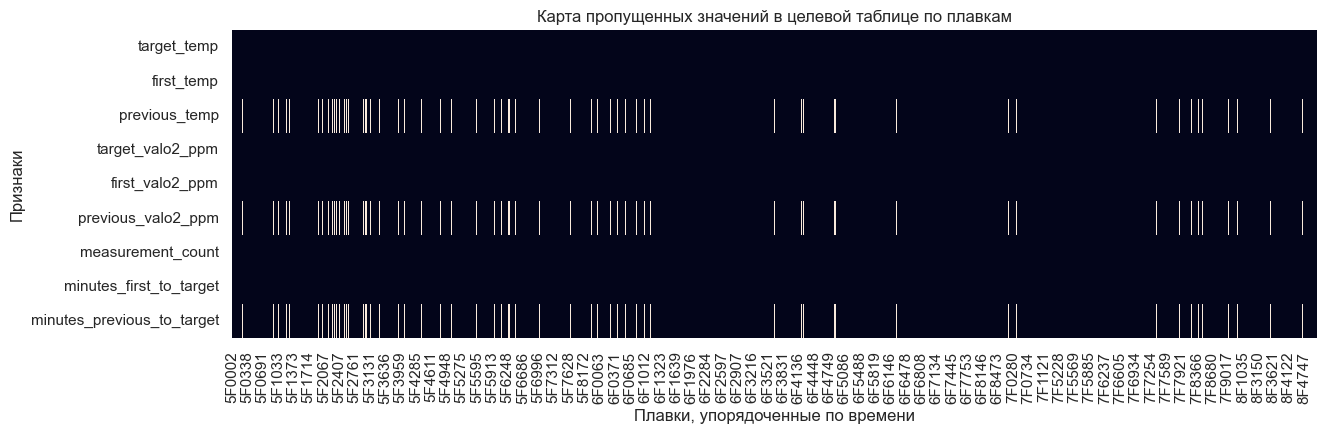

In [123]:
missing_cols = [
    'target_temp', 'first_temp', 'previous_temp',
    'target_valo2_ppm', 'first_valo2_ppm', 'previous_valo2_ppm',
    'measurement_count', 'minutes_first_to_target', 'minutes_previous_to_target'
]

missing_map = heat_temp[missing_cols].isna().T

plt.figure(figsize=(14, 4))
sns.heatmap(missing_map, cbar=False)
plt.title('Карта пропущенных значений в целевой таблице по плавкам')
plt.xlabel('Плавки, упорядоченные по времени')
plt.ylabel('Признаки')
plt.show()

* **target_temp** — пропусков нет. Это главное: целевая переменная заполнена для всех плавок.
* **first_temp** — пропусков нет. Первое измерение температуры есть у каждой плавки.
* **target_valo2_ppm** — пропусков нет как NaN, но есть 0, что означает, что измерение окисления не проводилось.
* **first_valo2_ppm**, **measurement_count**, **minutes_first_to_target** — пропусков нет.

Пропуски видны в строках:

-> previous_temp;
-> previous_valo2_ppm;
-> minutes_previous_to_target.

Это логично: эти признаки существуют только если у плавки было минимум два измерения температуры. Если плавка имеет только одно измерение, то “предыдущего перед конечным” измерения просто нет. То есть пропуски в previous_* — не ошибка данных, а структурная особенность процесса.

Карта пропущенных значений показывает, что целевая переменная target_temp, первое измерение температуры и базовые признаки по числу измерений заполнены для всех плавок. Пропуски наблюдаются только в признаках previous_temp, previous_valo2_ppm и minutes_previous_to_target, что связано с плавками, имеющими только одно измерение температуры. Эти пропуски имеют содержательную природу, поэтому при моделировании их следует обрабатывать отдельно: добавить флаг has_previous_temp, а числовые значения заполнить, например, первым измерением, медианой или специальным значением.

### Создание признаков

Значения VALO2_PPM = 0 и VALO2_PPM = 9999 рассматриваются как отсутствующие или технически некорректные измерения. Для предотвращения утечки будущей информации при моделировании используется только заполнение предыдущим известным значением внутри плавки, а также бинарный флаг факта измерения. Оставшиеся пропуски заполняются на этапе preprocessing по обучающей выборке.

In [124]:
df_temp['VALO2_PPM_clean'] = df_temp['VALO2_PPM'].where(
    (df_temp['VALO2_PPM'] > 0) & (df_temp['VALO2_PPM'] < 9999),
    np.nan
)

Создаем флаг факта измерения:

In [125]:
df_temp['VALO2_PPM_measured'] = df_temp['VALO2_PPM_clean'].notna()

Для признаков модели используем заполнение только из прошлого внутри той же плавки:

In [126]:
df_temp['VALO2_PPM_ffill'] = (
    df_temp
    .groupby('HEATID')['VALO2_PPM_clean']
    .ffill()
)

Сформируем первичный датасет. Для того чтобы не допустить утечки будущей информации я агрегирую технологические таблицы только по событиям, которые произошли **не позже времени целевого измерения температуры** ( target_time ).

На этом этапе добавляю признаки:

* по температурным измерениям: первое и предыдущее измерение, число измерений, временные интервалы;
* по трансформатору: суммарное потребление **MW**, длительность работы, ступени **TAP**;
* по газу/кислороду: накопленные объемы и потоки до целевого измерения;
* по углеродной продувке: накопленный расход и поток до целевого измерения;
* по загрузке и добавкам в ДСП: суммарные массы и число позиций до целевого измерения.

In [127]:
target_times = heat_temp[['target_time']].reset_index()

def parse_duration_minutes(series):
    '''Парсинг длительности вида ' 00: 30' в минуты.'''
    parts = series.astype(str).str.extract(r'(\d+)\s*:\s*(\d+)')
    return pd.to_numeric(parts[0], errors='coerce') * 60 + pd.to_numeric(parts[1], errors='coerce')


def filter_before_target(df, time_col):
    df = df.merge(target_times, on='HEATID', how='inner')
    return df[df[time_col].le(df['target_time'])].drop(columns='target_time')

In [ ]:
transformer = pd.read_csv(DATA_DIR / 'eaf_transformer.csv')
transformer['STARTTIME'] = parse_datetime(transformer['STARTTIME'])
transformer['MW'] = ru_to_float(transformer['MW'])
transformer['duration_min'] = parse_duration_minutes(transformer['DURATION'])
transformer = filter_before_target(transformer, 'STARTTIME')

transformer_features = transformer.groupby('HEATID').agg(
    transformer_rows=('HEATID', 'size'),
    transformer_total_mw=('MW', 'sum'),
    transformer_mean_mw=('MW', 'mean'),
    transformer_max_mw=('MW', 'max'),
    transformer_total_duration_min=('duration_min', 'sum'),
    transformer_mean_tap=('TAP', 'mean'),
    transformer_max_tap=('TAP', 'max'),
).reset_index()

transformer_features.head()

,HEATID,transformer_rows,transformer_total_mw,transformer_mean_mw,transformer_max_mw,transformer_total_duration_min,transformer_mean_tap,transformer_max_tap
0,5F0002,8,48.625,6.078125,29.125,1010.0,13.000000,15
1,5F0003,8,48.625,6.078125,28.750,2010.0,13.125000,15
2,5F0004,13,47.375,3.644231,18.125,2060.0,13.230769,15
3,5F0005,11,49.250,4.477273,27.875,2141.0,13.636364,15
4,5F0006,11,49.875,4.534091,28.000,2100.0,13.454545,15


In [ ]:
def aggregate_stream_table(file_name, 
                           time_col, 
                           numeric_cols, 
                           prefix, 
                           chunksize=500_000):
    partials = []
    usecols = ['HEATID', time_col] + numeric_cols

    for chunk in pd.read_csv(DATA_DIR / file_name, 
                             usecols=usecols, 
                             chunksize=chunksize):
        
        chunk[time_col] = parse_datetime(chunk[time_col])
        for col in numeric_cols:
            chunk[col] = ru_to_float(chunk[col])

        chunk = filter_before_target(chunk, time_col)
        if chunk.empty:
            continue

        agg_spec = { f'{prefix}_rows': ('HEATID', 'size'),
            f'{prefix}_time_start': (time_col, 'min'),
            f'{prefix}_time_end': (time_col, 'max'),  }

        for col in numeric_cols:
            col_name = col.lower()
            agg_spec[f'{prefix}_{col_name}_max'] = (col, 'max')
            agg_spec[f'{prefix}_{col_name}_sum'] = (col, 'sum')

        partials.append(chunk.groupby('HEATID').agg(**agg_spec).reset_index())

    partial = pd.concat(partials, ignore_index=True)

    combine_spec = { f'{prefix}_rows': (f'{prefix}_rows', 'sum'),
                     f'{prefix}_time_start': (f'{prefix}_time_start', 'min'),
                    f'{prefix}_time_end': (f'{prefix}_time_end', 'max'), }

    for col in numeric_cols:
        col_name = col.lower()
        combine_spec[f'{prefix}_{col_name}_max'] = (f'{prefix}_{col_name}_max', 'max')
        combine_spec[f'{prefix}_{col_name}_sum'] = (f'{prefix}_{col_name}_sum', 'sum')

    result = partial.groupby('HEATID').agg(**combine_spec).reset_index()

    for col in numeric_cols:
        col_name = col.lower()
        result[f'{prefix}_{col_name}_mean'] = result[f'{prefix}_{col_name}_sum'] / result[f'{prefix}_rows']

    return result


gaslance_features = aggregate_stream_table( file_name='eaf_gaslance_mat.csv',
                                            time_col='REVTIME',
                                            numeric_cols=['O2_AMOUNT', 'GAS_AMOUNT',
                                                           'O2_FLOW', 'GAS_FLOW'],
                                            prefix='gaslance',)

inj_features = aggregate_stream_table( file_name='inj_mat.csv',
                                       time_col='REVTIME',
                                       numeric_cols=['INJ_AMOUNT_CARBON',
                                                     'INJ_FLOW_CARBON'],
                                                     prefix='inj', )

display(gaslance_features.head())
display(inj_features.head())

,HEATID,gaslance_rows,gaslance_time_start,gaslance_time_end,gaslance_o2_amount_max,gaslance_o2_amount_sum,gaslance_gas_amount_max,gaslance_gas_amount_sum,gaslance_o2_flow_max,gaslance_o2_flow_sum,gaslance_gas_flow_max,gaslance_gas_flow_sum,gaslance_o2_amount_mean,gaslance_gas_amount_mean,gaslance_o2_flow_mean,gaslance_gas_flow_mean
0,5F0002,248,2015-01-01 00:50:37.617,2015-01-01 01:31:58.289,3796.0,368154.0,1141.0,155556.0,5992.0,1030335.0,2562.0,398363.0,1484.491935,627.241935,4154.576613,1606.302419
1,5F0003,236,2015-01-01 01:38:17.492,2015-01-01 02:17:57.476,3659.0,341620.0,1160.0,142793.0,6197.0,911545.0,2582.0,376131.0,1447.542373,605.055085,3862.478814,1593.775424
2,5F0004,321,2015-01-01 02:23:12.664,2015-01-01 03:17:52.664,3469.0,542868.0,1156.0,230271.0,6383.0,1029755.0,2702.0,393419.0,1691.177570,717.355140,3207.959502,1225.604361
3,5F0005,247,2015-01-01 03:24:45.070,2015-01-01 04:06:55.070,3605.0,384778.0,1204.0,157238.0,6191.0,1032398.0,2546.0,391933.0,1557.805668,636.591093,4179.748988,1586.773279
4,5F0006,258,2015-01-01 04:13:27.508,2015-01-01 04:56:57.617,3678.0,417360.0,1191.0,164697.0,7350.0,1026655.0,2585.0,396124.0,1617.674419,638.360465,3979.282946,1535.364341


,HEATID,inj_rows,inj_time_start,inj_time_end,inj_inj_amount_carbon_max,inj_inj_amount_carbon_sum,inj_inj_flow_carbon_max,inj_inj_flow_carbon_sum,inj_inj_amount_carbon_mean,inj_inj_flow_carbon_mean
0,5F0002,202,2015-01-01 00:50:37.586,2015-01-01 01:31:58.289,1051.0,28543.0,122.0,5212.0,141.301980,25.801980
1,5F0003,200,2015-01-01 01:38:17.476,2015-01-01 02:17:27.445,845.0,26451.0,114.0,5371.0,132.255000,26.855000
2,5F0004,197,2015-01-01 02:23:12.648,2015-01-01 03:17:52.648,660.0,18777.0,108.0,4200.0,95.314721,21.319797
3,5F0005,201,2015-01-01 03:24:45.039,2015-01-01 04:06:55.055,692.0,25176.0,87.0,4367.0,125.253731,21.726368
4,5F0006,207,2015-01-01 04:13:27.492,2015-01-01 04:56:27.586,812.0,33027.0,90.0,4873.0,159.550725,23.541063


In [130]:
def aggregate_material_table(file_name, amount_col, date_col, prefix):

    df = pd.read_csv(DATA_DIR / file_name)
    df[date_col] = parse_datetime(df[date_col])
    df[amount_col] = ru_to_float(df[amount_col])
    df = filter_before_target(df, date_col)

    return df.groupby('HEATID').agg(
        **{
            f'{prefix}_rows': ('HEATID', 'size'),
            f'{prefix}_total_amount': (amount_col, 'sum'),
            f'{prefix}_mean_amount': (amount_col, 'mean'),
            f'{prefix}_max_amount': (amount_col, 'max'),
            f'{prefix}_unique_materials': ('MAT_CODE', 'nunique'),
            f'{prefix}_time_start': (date_col, 'min'),
            f'{prefix}_time_end': (date_col, 'max'),
        }
    ).reset_index()


basket_features = aggregate_material_table( file_name='basket_charged.csv',
                                            amount_col='CHARGED_AMOUNT',
                                            date_col='DATETIME',
                                            prefix='basket', )

eaf_added_features = aggregate_material_table( file_name='eaf_added_materials.csv',
                                               amount_col='CHARGE_AMOUNT',
                                               date_col='DATETIME',
                                               prefix='eaf_added', )

display(basket_features.head())
display(eaf_added_features.head())

,HEATID,basket_rows,basket_total_amount,basket_mean_amount,basket_max_amount,basket_unique_materials,basket_time_start,basket_time_end
0,5F0002,6,128590.0,21431.666667,49289.0,3,2015-01-01 00:51:00,2015-01-01 01:09:00
1,5F0003,6,128826.0,21471.000000,49623.0,3,2015-01-01 01:39:00,2015-01-01 01:55:00
2,5F0004,4,133715.0,33428.750000,73790.0,2,2015-01-01 02:24:00,2015-01-01 02:41:00
3,5F0005,6,129233.0,21538.833333,49633.0,3,2015-01-01 03:25:00,2015-01-01 03:43:00
4,5F0006,4,132505.0,33126.250000,72600.0,2,2015-01-01 04:15:00,2015-01-01 04:32:00


,HEATID,eaf_added_rows,eaf_added_total_amount,eaf_added_mean_amount,eaf_added_max_amount,eaf_added_unique_materials,eaf_added_time_start,eaf_added_time_end
0,5F0002,4,2763.0,690.75,835.0,4,2015-01-01 01:02:00,2015-01-01 01:29:00
1,5F0003,4,2758.0,689.50,831.0,4,2015-01-01 01:50:00,2015-01-01 02:15:00
2,5F0004,4,4055.0,1013.75,1810.0,4,2015-01-01 02:36:00,2015-01-01 03:18:00
3,5F0005,4,2753.0,688.25,829.0,4,2015-01-01 03:36:00,2015-01-01 04:04:00
4,5F0006,4,4054.0,1013.50,1810.0,4,2015-01-01 04:27:00,2015-01-01 04:55:00


In [ ]:
feature_df = heat_temp.reset_index().merge(transformer_features, on='HEATID', how='left')
feature_df = feature_df.merge(gaslance_features, on='HEATID', how='left')
feature_df = feature_df.merge(inj_features, on='HEATID', how='left')
feature_df = feature_df.merge(basket_features, on='HEATID', how='left')
feature_df = feature_df.merge(eaf_added_features, on='HEATID', how='left')


count_like_cols = [c for c in feature_df.columns if c.endswith('_rows') or c.endswith('_unique_materials')]
amount_like_cols = [ c for c in feature_df.columns
                     if ('_total_' in c or c.endswith('_amount_max') 
                           or c.endswith('_amount_sum') or c.endswith('_flow_sum'))
                   ]

for col in count_like_cols + amount_like_cols:
    if col in feature_df.columns:
        feature_df[col] = feature_df[col].fillna(0)

feature_df = feature_df.sort_values('target_time').reset_index(drop=True)
feature_df.head()

,HEATID,target_time,target_temp,target_valo2_ppm,measurement_count,first_temp_time,first_temp,first_valo2_ppm,previous_temp_time,previous_temp,...,basket_unique_materials,basket_time_start,basket_time_end,eaf_added_rows,eaf_added_total_amount,eaf_added_mean_amount,eaf_added_max_amount,eaf_added_unique_materials,eaf_added_time_start,eaf_added_time_end
0,5F0002,2015-01-01 01:32:00,1650.0,403.0,3,2015-01-01 01:30:00,1598.0,366.0,2015-01-01 01:31:00,1633.0,...,3.0,2015-01-01 00:51:00,2015-01-01 01:09:00,4.0,2763.0,690.75,835.0,4.0,2015-01-01 01:02:00,2015-01-01 01:29:00
1,5F0003,2015-01-01 02:18:00,1653.0,698.0,2,2015-01-01 02:17:00,1629.0,668.0,2015-01-01 02:17:00,1629.0,...,3.0,2015-01-01 01:39:00,2015-01-01 01:55:00,4.0,2758.0,689.50,831.0,4.0,2015-01-01 01:50:00,2015-01-01 02:15:00
2,5F0004,2015-01-01 03:18:00,1636.0,700.0,2,2015-01-01 03:17:00,1636.0,700.0,2015-01-01 03:17:00,1636.0,...,2.0,2015-01-01 02:24:00,2015-01-01 02:41:00,4.0,4055.0,1013.75,1810.0,4.0,2015-01-01 02:36:00,2015-01-01 03:18:00
3,5F0005,2015-01-01 04:07:00,1641.0,669.0,3,2015-01-01 04:05:00,1621.0,592.0,2015-01-01 04:06:00,1628.0,...,3.0,2015-01-01 03:25:00,2015-01-01 03:43:00,4.0,2753.0,688.25,829.0,4.0,2015-01-01 03:36:00,2015-01-01 04:04:00
4,5F0006,2015-01-01 04:57:00,1651.0,789.0,4,2015-01-01 04:53:00,1620.0,624.0,2015-01-01 04:55:00,1611.0,...,2.0,2015-01-01 04:15:00,2015-01-01 04:32:00,4.0,4054.0,1013.50,1810.0,4.0,2015-01-01 04:27:00,2015-01-01 04:55:00


In [132]:
print(f'Размер итоговой таблицы признаков: {feature_df.shape}')
print(f"Число плавок: {feature_df['HEATID'].nunique():,}")
print(f"Пропусков всего: {feature_df.isna().sum().sum():,}")

feature_df.filter(regex='target|first|previous|transformer|gaslance|inj|basket|eaf_added').describe().T.head(30)

Размер итоговой таблицы признаков: (20827, 62)
Число плавок: 20,827
Пропусков всего: 6,580


,count,mean,min,25%,50%,75%,max,std
target_time,20827,2016-07-16 11:30:39.151101952,2015-01-01 01:32:00,2015-09-17 16:18:00,2016-06-01 09:10:00,2017-02-16 11:45:00,2018-07-29 09:16:00,NaN
target_temp,20827.0,1649.84837,1499.0,1641.0,1650.0,1658.0,1850.0,13.872232
target_valo2_ppm,20827.0,877.699381,0.0,747.0,872.0,1013.0,9999.0,374.388159
first_temp_time,20827,2016-07-16 11:22:44.189753856,2015-01-01 01:30:00,2015-09-17 15:22:30,2016-06-01 09:10:00,2017-02-16 11:38:00,2018-07-29 09:12:00,NaN
first_temp,20827.0,1620.041485,1411.0,1600.0,1619.0,1640.0,1800.0,29.857315
first_valo2_ppm,20827.0,822.365795,0.0,397.0,681.0,878.0,9999.0,1470.062253
previous_temp_time,19736,2016-07-27 04:44:03.669436672,2015-01-01 01:31:00,2015-09-30 20:32:15,2016-06-16 09:54:30,2017-07-28 07:28:15,2018-07-29 09:14:00,NaN
previous_temp,19736.0,1638.8068,1115.0,1623.0,1638.0,1654.0,1791.0,24.170751
previous_valo2_ppm,19736.0,896.791874,0.0,596.0,844.0,1061.0,9999.0,1135.033856
minutes_first_to_target,20827.0,7.916022,0.0,2.0,4.0,7.0,1341.0,31.18685


## Визуализация временного ряда


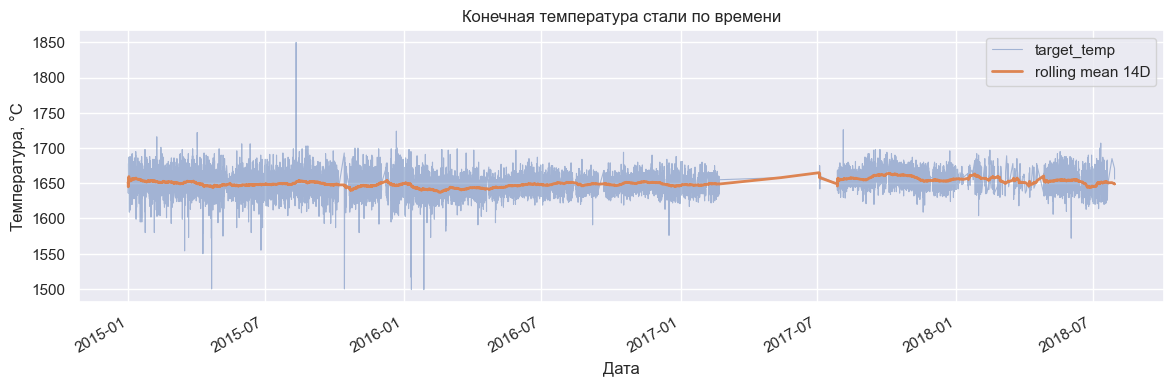

In [133]:
ax = df_target['target_temp'].plot(figsize=(14, 4), alpha=0.45, linewidth=0.8)
df_target['target_temp'].rolling('14D').mean().plot(ax=ax, linewidth=2, label='rolling mean 14D')
ax.set_title('Конечная температура стали по времени')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()

На графике наблюдается длительный период отсутствия данных примерно с конца февраля до начала июля 2017 года. Проверка дополнительных таблиц, описывающих технологический процесс показывает, что в этот период отсутствуют не только измерения температуры, но и записи о работе трансформатора, подаче газа/кислорода, инжекции углерода и загрузке материалов. Это может соответствовать остановке печи, плановому ремонту, простою производства или отсутствию выгрузки данных за данный период. По имеющимся данным невозможно однозначно отличить физический простой от пропуска в системе сбора данных, поэтому данный интервал следует трактовать как длительный разрыв наблюдений.

Для моделирования важно:

- не интерполировать этот период как реальные температуры;
- календарный график может визуально соединять точки до и после разрыва, но это не означает, что значения существовали внутри данной паузы;
- для прогноза лучше использовать heat_seq, то есть порядковый номер плавки;
- стоит отдельно отметить возможный сменный режим после простоя: после июля 2017 года медианная температура выглядит чуть выше, это может быть технологический сдвиг после перезапуска/ремонта.

#### Распределение целевой переменной

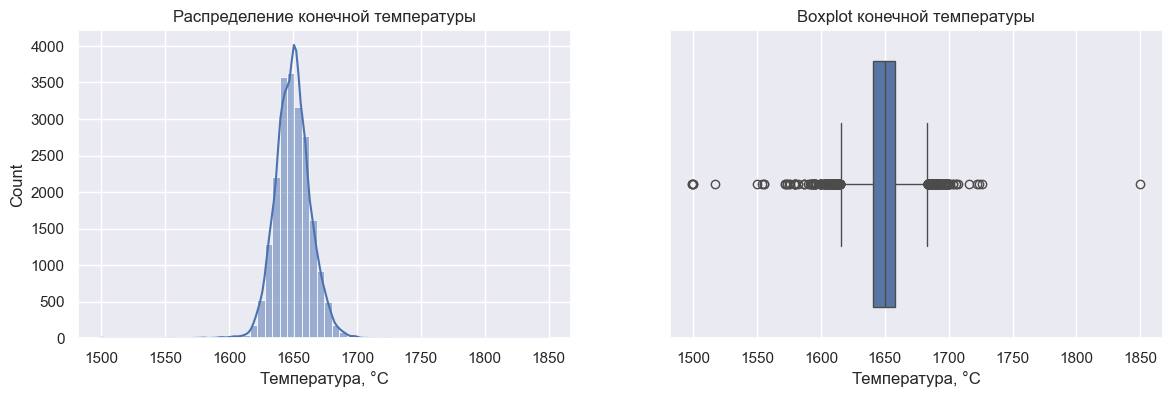

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(feature_df['target_temp'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Распределение конечной температуры')
axes[0].set_xlabel('Температура, °C')

sns.boxplot(x=feature_df['target_temp'], ax=axes[1])
axes[1].set_title('Boxplot конечной температуры')
axes[1].set_xlabel('Температура, °C')

plt.show()

Посмотрим агрегированную динамику по неделям. Это сглаживает шум отдельных плавок и помогает увидеть долгосрочные изменения режима производства.

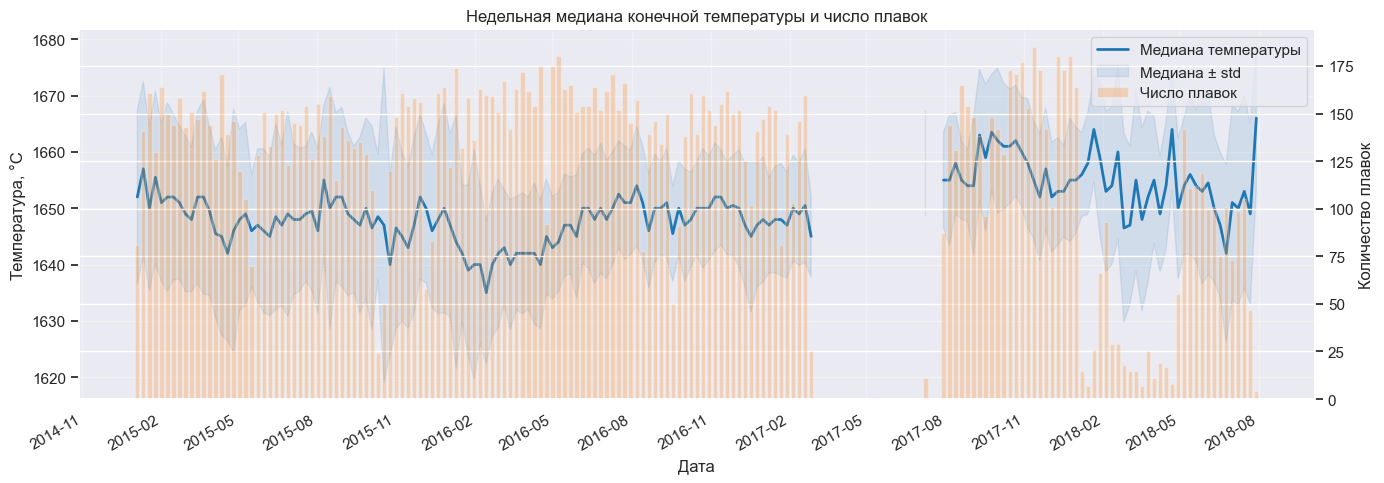

In [135]:
weekly_target = df_target['target_temp'].resample('1W').agg(['mean', 'median', 'std', 'count'])

fig, ax_temp = plt.subplots(figsize=(14, 5))

ax_temp.plot(
    weekly_target.index,
    weekly_target['median'],
    color='tab:blue',
    linewidth=2,
    label='Медиана температуры',
)
ax_temp.fill_between(
    weekly_target.index,
    weekly_target['median'] - weekly_target['std'],
    weekly_target['median'] + weekly_target['std'],
    color='tab:blue',
    alpha=0.12,
    label='Медиана ± std',
)
ax_temp.set_ylabel('Температура, °C')
ax_temp.set_xlabel('Дата')
ax_temp.grid(True, alpha=0.3)

ax_count = ax_temp.twinx()
ax_count.bar(
    weekly_target.index,
    weekly_target['count'],
    width=5,
    color='tab:orange',
    alpha=0.25,
    label='Число плавок',
)
ax_count.set_ylabel('Количество плавок')

lines_1, labels_1 = ax_temp.get_legend_handles_labels()
lines_2, labels_2 = ax_count.get_legend_handles_labels()
ax_temp.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

ax_temp.set_title('Недельная медиана конечной температуры и число плавок')
ax_temp.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_temp.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Визуализация по одной плавки

Визуализирую пример динамики технологического процесса внутри одной плавки: измерения температуры, кислород/газ и инжекция углерода.

Пример плавки: 5F0024


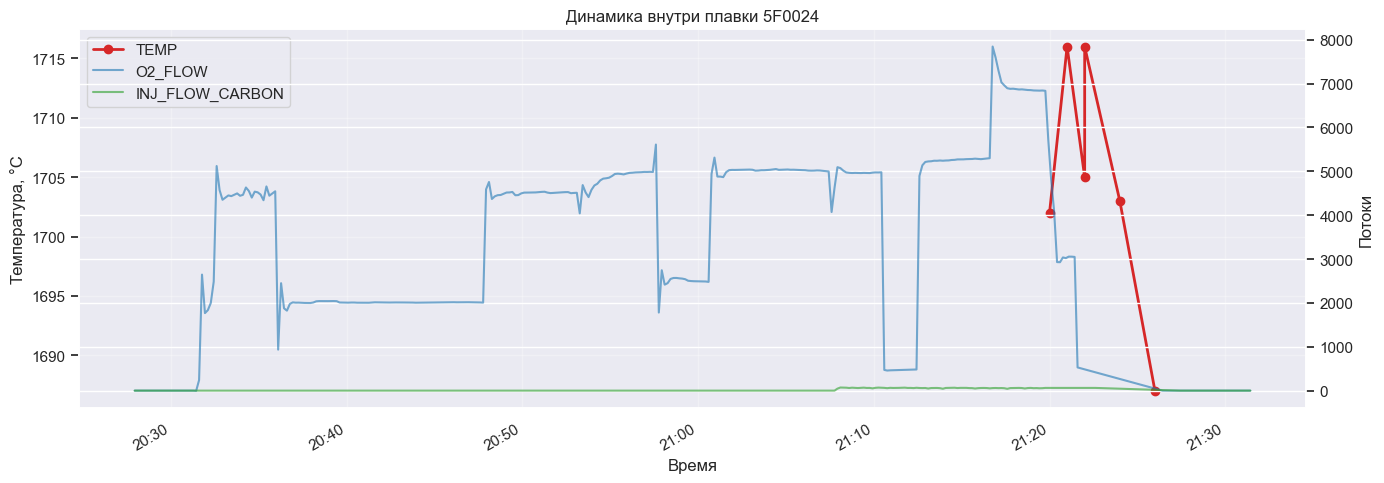

In [ ]:
example_heat_id = heat_temp.query('measurement_count >= 5').index[0]
print('Пример плавки:', example_heat_id)

example_temp = df_temp[df_temp['HEATID'] == example_heat_id].copy()

def read_heat_rows(file_name, heat_id, chunksize=500_000):

    parts = []

    for chunk in pd.read_csv(DATA_DIR / file_name, chunksize=chunksize):
        part = chunk[chunk['HEATID'] == heat_id].copy()
        if not part.empty:
            parts.append(part)

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


example_gas = read_heat_rows('eaf_gaslance_mat.csv', example_heat_id)

if not example_gas.empty:
    example_gas['REVTIME'] = parse_datetime(example_gas['REVTIME'])
    for col in ['O2_AMOUNT', 'GAS_AMOUNT', 'O2_FLOW', 'GAS_FLOW']:
        example_gas[col] = ru_to_float(example_gas[col])

example_inj = read_heat_rows('inj_mat.csv', example_heat_id)

if not example_inj.empty:
    example_inj['REVTIME'] = parse_datetime(example_inj['REVTIME'])
    for col in ['INJ_AMOUNT_CARBON', 'INJ_FLOW_CARBON']:
        example_inj[col] = ru_to_float(example_inj[col])

fig, ax_temp = plt.subplots(figsize=(14, 5))

ax_temp.plot( example_temp['DATETIME'],
              example_temp['TEMP'],
              marker='o',
              color='tab:red',
              linewidth=2,
              label='TEMP',)

ax_temp.set_ylabel('Температура, °C')
ax_temp.set_xlabel('Время')
ax_temp.grid(True, alpha=0.3)

ax_flow = ax_temp.twinx()

if not example_gas.empty:

    ax_flow.plot( example_gas['REVTIME'],
                  example_gas['O2_FLOW'],
                  color='tab:blue',
                  alpha=0.6,
                  label='O2_FLOW',)

if not example_inj.empty:

    ax_flow.plot( example_inj['REVTIME'],
                  example_inj['INJ_FLOW_CARBON'],
                  color='tab:green',
                  alpha=0.6,
                  label='INJ_FLOW_CARBON', )

ax_flow.set_ylabel('Потоки')

lines_1, labels_1 = ax_temp.get_legend_handles_labels()
lines_2, labels_2 = ax_flow.get_legend_handles_labels()
ax_temp.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

ax_temp.set_title(f'Динамика внутри плавки {example_heat_id}')
ax_temp.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Графики показывают, что конечная температура в целом поддерживается в узком технологическом диапазоне, однако во временном ряду присутствует длительный производственный разрыв и возможный сдвиг режима после 2017 года. Анализ отдельной плавки показывает, что температура измеряется дискретно, тогда как технологические параметры фиксируются чаще и меняются ступенчато.

### Оценка влияния технологических факторов на конечную температуру


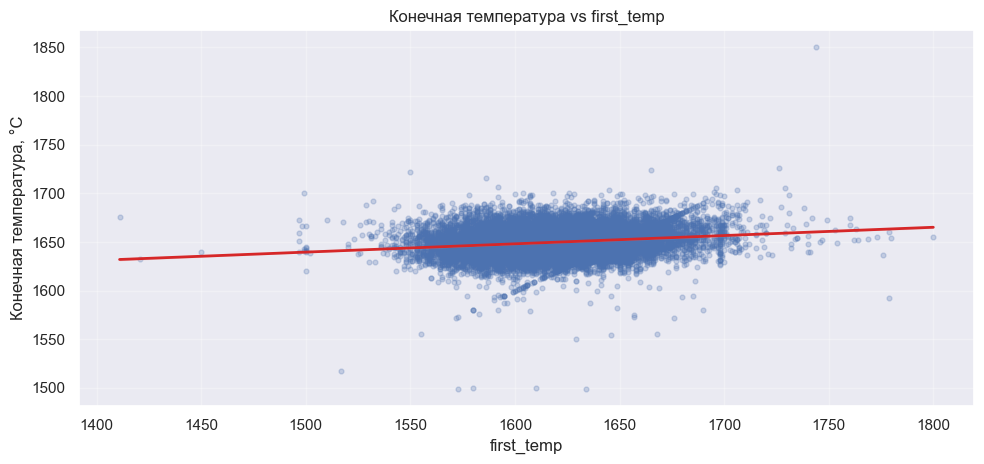

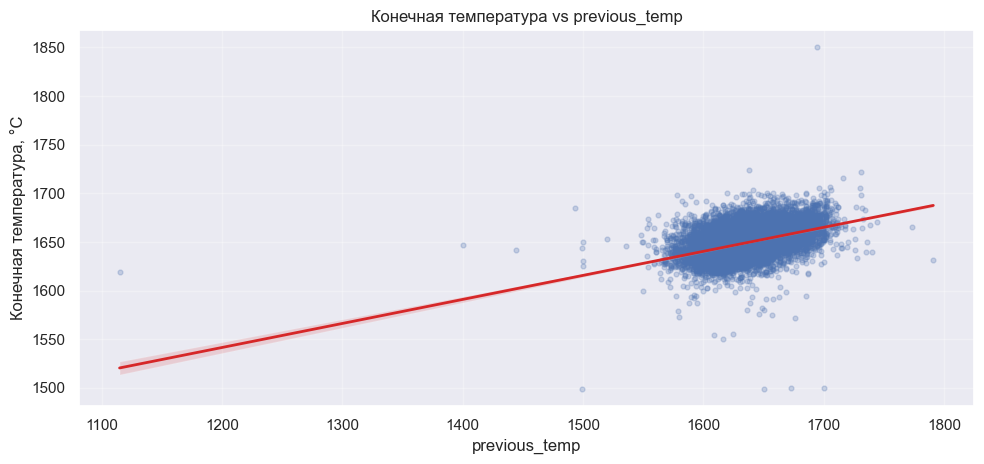

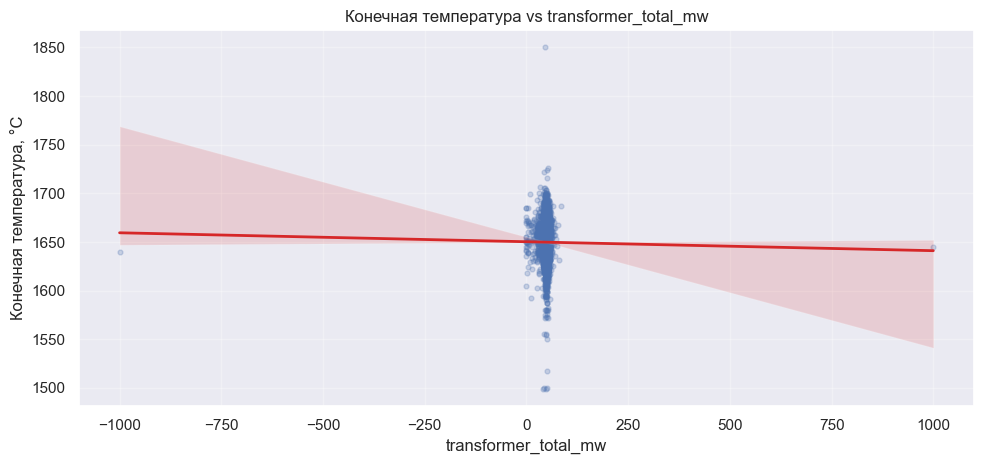

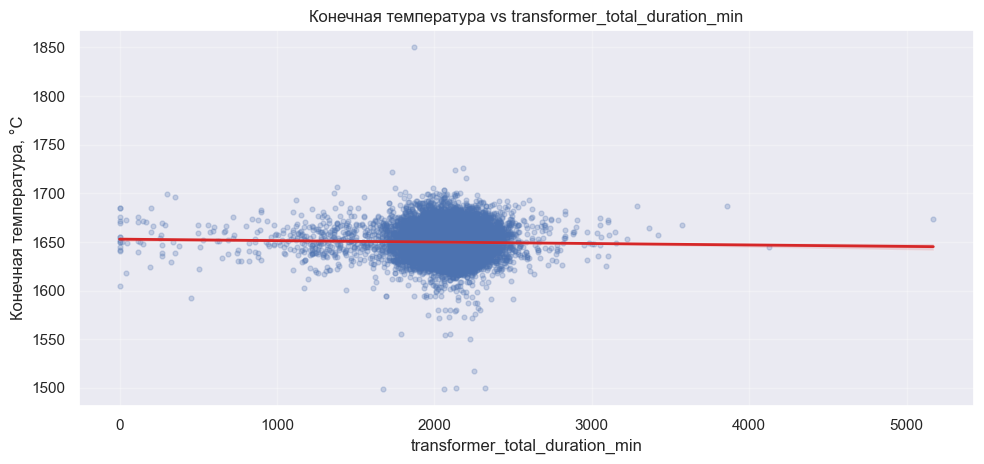

In [137]:
scatter_cols = [ 'first_temp',
                 'previous_temp',
                 'transformer_total_mw',
                 'transformer_total_duration_min',
                 'gaslance_o2_amount_max',
                 'gaslance_gas_amount_max',
                 'inj_inj_amount_carbon_max',
                 'basket_total_amount',
                 'eaf_added_total_amount',]

available_scatter_cols = [c for c in scatter_cols if c in feature_df.columns]

for col in available_scatter_cols[:4]:
    plot_data = feature_df[[col, 'target_temp']].dropna()

    fig, ax = plt.subplots(figsize=(10, 4.8))

    sns.regplot(data=plot_data,
                x=col,
                y='target_temp',
                scatter_kws={'alpha': 0.25, 's': 12},
                line_kws={'color': 'tab:red', 'linewidth': 2},
                ax=ax,)

    ax.set_title(f'Конечная температура vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Конечная температура, °C')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

##### Корреляционная матрица

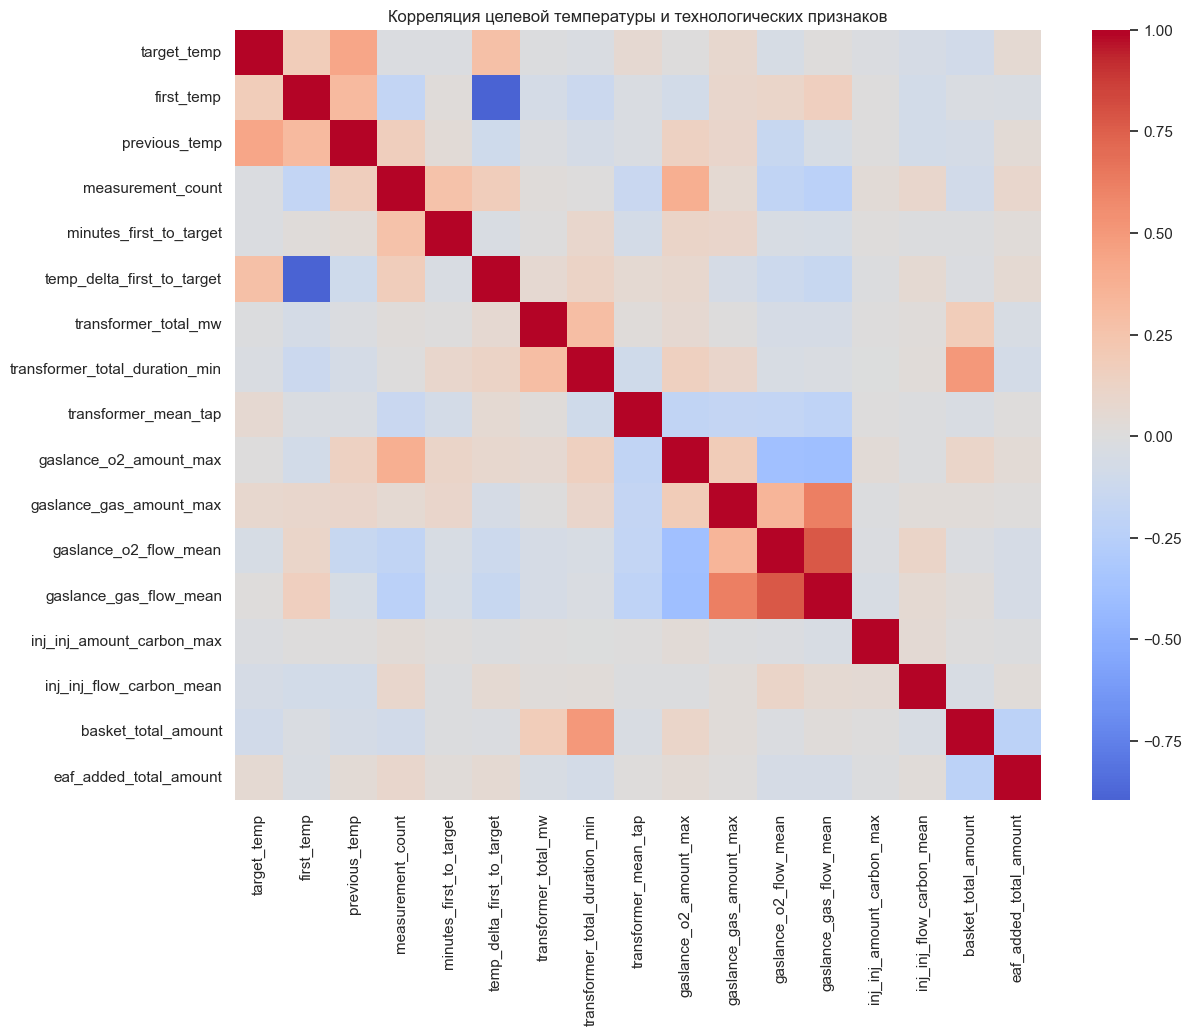

target_temp                       1.000000
previous_temp                     0.437083
temp_delta_first_to_target        0.275193
first_temp                        0.183218
gaslance_gas_amount_max           0.077938
transformer_mean_tap              0.062911
eaf_added_total_amount            0.058670
gaslance_gas_flow_mean            0.013876
gaslance_o2_amount_max            0.007168
transformer_total_mw             -0.007021
measurement_count                -0.016213
inj_inj_amount_carbon_max        -0.016815
minutes_first_to_target          -0.020697
transformer_total_duration_min   -0.021892
gaslance_o2_flow_mean            -0.044142
inj_inj_flow_carbon_mean         -0.055529
basket_total_amount              -0.090205
Name: target_temp, dtype: float64

In [138]:
eda_numeric_cols = [ 'target_temp',
                     'first_temp',
                     'previous_temp',
                     'measurement_count',
                     'minutes_first_to_target',
                     'temp_delta_first_to_target',
                     'transformer_total_mw',
                     'transformer_total_duration_min',
                     'transformer_mean_tap',
                     'gaslance_o2_amount_max',
                     'gaslance_gas_amount_max',
                     'gaslance_o2_flow_mean',
                     'gaslance_gas_flow_mean',
                     'inj_inj_amount_carbon_max',
                     'inj_inj_flow_carbon_mean',
                     'basket_total_amount',
                     'eaf_added_total_amount',]

eda_numeric_cols = [c for c in eda_numeric_cols if c in feature_df.columns]

corr = feature_df[eda_numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Корреляция целевой температуры и технологических признаков')
plt.show()

corr['target_temp'].sort_values(ascending=False)

-> Первая измеренная температура имеет положительную связь с конечной температурой, но связь не очень сильная. Основная масса плавок начинается в диапазоне примерно 1550-1700 °C, а конечная температура чаще находится около 1620-1680 °C.

Это означает, что первая температура полезна как базовый признак, но сама по себе плохо объясняет итоговую температуру: между первым и последним замером процесс еще активно управляется нагревом, кислородом, добавками, углеродной продувкой и технологическими корректировками.


-> Предыдущее измерение температуры связано с конечной температурой заметно сильнее, чем первое измерение. Линия тренда имеет более выраженный положительный наклон, а облако точек выглядит плотнее.

Это логично: previous_temp ближе по времени к моменту выпуска плавки, поэтому лучше отражает текущее состояние металла. Для модели это один из наиболее важных признаков. При этом признак есть не для всех плавок, поэтому нужно учитывать флаг наличия предыдущего измерения или отдельно обрабатывать плавки с единственным замером.

Связь агрегированного признака для трансформатора с конечной температурой выражена слабо. Линия тренда почти горизонтальная, а отдельные экстремальные значения сильно растягивают график.

Это говорит о том, что текущий агрегированный признак transformer_total_mw в таком виде может быть малоинформативен. 

Суммарная длительность работы трансформатора также не показывает явной линейной связи с конечной температурой. Большая часть точек сосредоточена в одном диапазоне, но есть заметные выбросы по длительности.

**Вывод:** длительность сама по себе не определяет конечную температуру, потому что результат зависит не только от времени нагрева, но и от режима мощности, начальной температуры, состава шихты, кислорода, углерода и добавок. 

## Оценка сезонных составляющих

### Поиск сезонных составляющих

Вряд ли мы увидим сильную сезонность: температура управляется технологически. Но возможны производственные эффекты: смена режимов, кампания печи, качество шихты и т.д.

Для оценки используем дневную медиану конечной температуры.

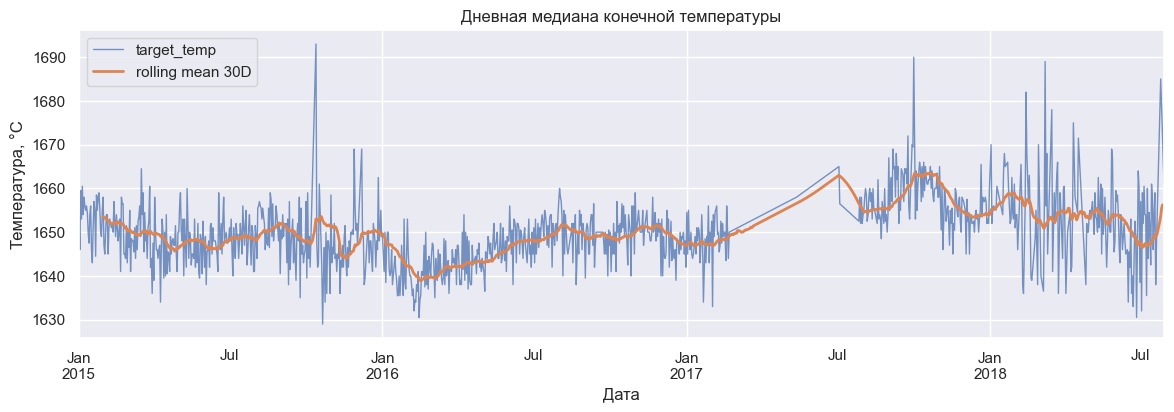

In [139]:
daily_target = df_target['target_temp'].resample('1D').median()
daily_target_interpolated = daily_target.interpolate('time').ffill().bfill()

fig, ax = plt.subplots(figsize=(14, 4))
daily_target_interpolated.plot(ax=ax, linewidth=1, alpha=0.75)
daily_target_interpolated.rolling(30).mean().plot(ax=ax, linewidth=2, label='rolling mean 30D')
ax.set_title('Дневная медиана конечной температуры')
ax.set_xlabel('Дата')
ax.set_ylabel('Температура, °C')
ax.legend()
plt.show()

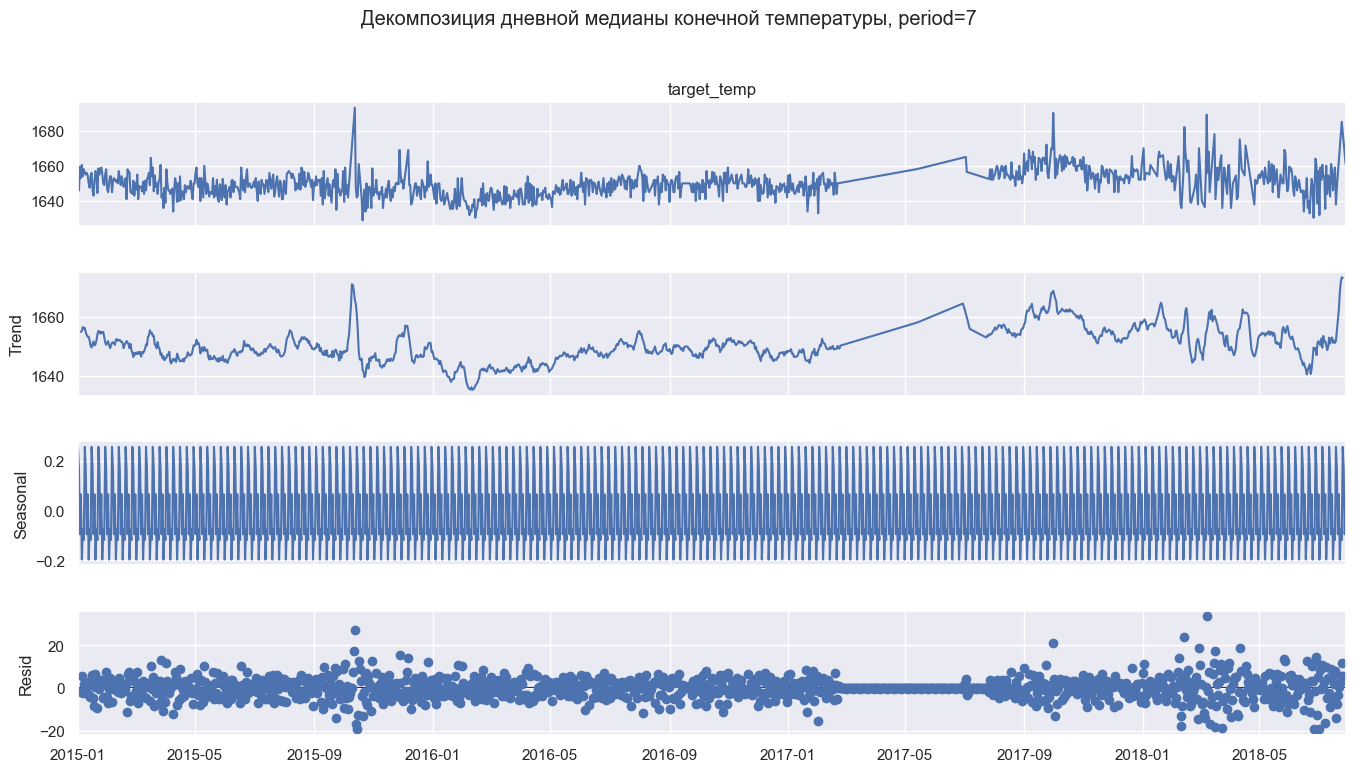

In [140]:
decomposition = seasonal_decompose(daily_target_interpolated, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Декомпозиция дневной медианы конечной температуры, period=7', y=1.02)
plt.show()

-> Дневная медиана конечной температуры в целом держится в устойчивом рабочем диапазоне около 1645-1655 °C. В начале 2016 года наблюдается снижение медианного уровня, а после длительного разрыва в данных в 2017 году температура выходит на немного более высокий уровень. В 2018 году колебания становятся заметно сильнее, что может указывать на более нестабильный режим работы или большее число нестандартных плавок.

-> Декомпозиция показывает, что основная динамика ряда определяется трендом и случайными отклонениями. Недельная сезонность при практически незначима: ее амплитуда очень мала по сравнению с разбросом температуры. Остатки содержат отдельные выбросы, особенно в 2017-2018 годах, поэтому при дальнейшем моделировании важно учитывать аномальные значения и разрывы во временном ряду.

**Вывод**: ряд конечной температуры относительно стабильный, явной недельной сезонности нет, но есть трендовые сдвиги, разрыв в 2017 году и отдельные выбросы.

### Анализ редких регулярных событий

Здесь посмотрим распределение конечной температуры по месяцам и годам. Это ближе к производственному процессу ДСП: возможны смены сырья, регламентов и режимов печи.

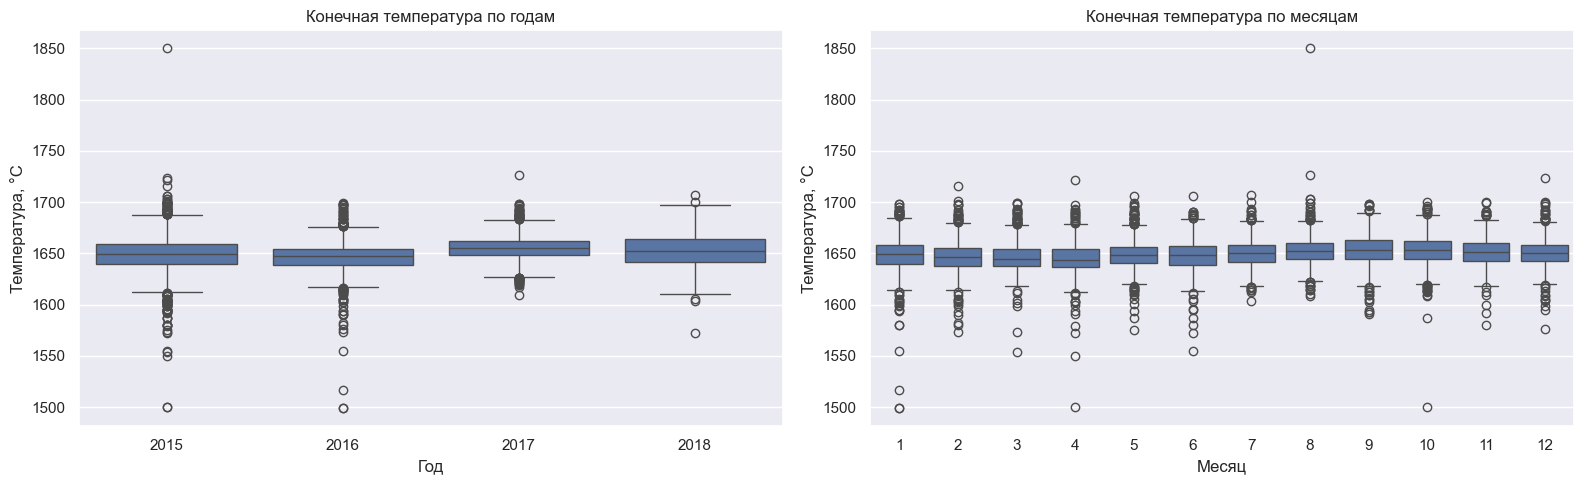

In [141]:
plot_df = feature_df.copy()
plot_df['year'] = plot_df['target_time'].dt.year
plot_df['month'] = plot_df['target_time'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=plot_df, x='year', y='target_temp', ax=axes[0])
axes[0].set_title('Конечная температура по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Температура, °C')

sns.boxplot(data=plot_df, x='month', y='target_temp', ax=axes[1])
axes[1].set_title('Конечная температура по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Температура, °C')

plt.tight_layout()
plt.show()

Итог: температурный режим по календарю в целом устойчивый, явной месячной сезонности нет, но есть отдельные выбросы и небольшой сдвиг уровня по годам.

### Оценка автокорреляции

Для статистических моделей важно понять, есть ли зависимость текущей конечной температуры от предыдущих плавок.

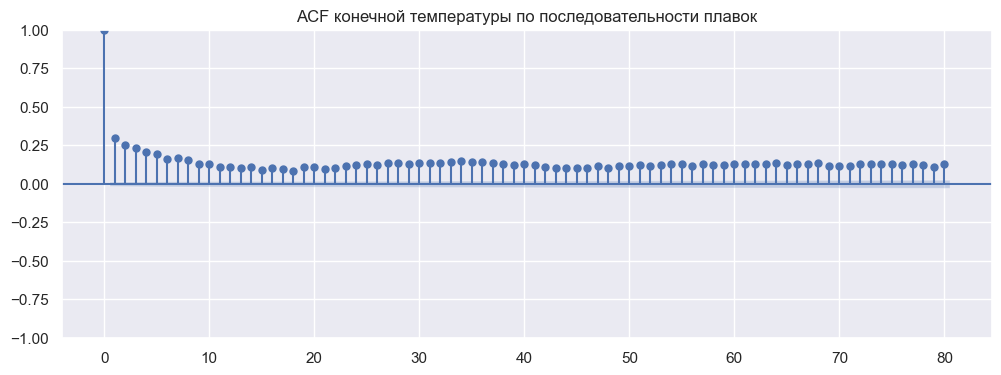

In [142]:
heat_sequence = feature_df.sort_values('heat_seq')['target_temp'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(heat_sequence, lags=80, ax=ax)
ax.set_title('ACF конечной температуры по последовательности плавок')
plt.show()

По графику видно, что автокорреляция конечной температуры положительная в начале. На первом "лаге" значение около 0.3, затем автокорреляция постепенно снижается, но остается положительной.

Это означает, что соседние по порядку плавки не являются полностью независимыми: Если предыдущие плавки имели более высокую или низкую конечную температуру, то следующие плавки с некоторой вероятностью будут находиться в похожем температурном режиме.

При этом автокорреляция не очень высокая, поэтому прошлые значения target_temp могут быть полезны как дополнительные признаки, но одной только истории конечной температуры недостаточно для точного прогноза. Для модели нужно использовать также технологические признаки конкретной плавки.

## Анализ многопеременного ВР

Сформирую две версии данных:

* **model_ts_df** — минимальный формат для статистического прогнозирования: unique_id, ds, y;
* **model_feature_df** — расширенная таблица признаков по плавкам для ML/DL и пайплайна.

In [143]:
model_ts_df = feature_df[['heat_seq', 'target_time', 'target_temp']].rename(
    columns={'heat_seq': 'ds', 'target_temp': 'y'}
)
model_ts_df.insert(0, 'unique_id', 'EAF_final_temperature')
model_ts_df = model_ts_df[['unique_id', 'ds', 'target_time', 'y']]

model_feature_df = feature_df.copy()

model_ts_df.head()

,unique_id,ds,target_time,y
0,EAF_final_temperature,0,2015-01-01 01:32:00,1650.0
1,EAF_final_temperature,1,2015-01-01 02:18:00,1653.0
2,EAF_final_temperature,2,2015-01-01 03:18:00,1636.0
3,EAF_final_temperature,3,2015-01-01 04:07:00,1641.0
4,EAF_final_temperature,4,2015-01-01 04:57:00,1651.0


### Учет лагов целевой переменной

In [144]:
model_feature_df = model_feature_df.sort_values('heat_seq').reset_index(drop=True)

for lag in [1, 2, 3, 5, 10, 20]:
    model_feature_df[f'target_temp_lag_{lag}'] = model_feature_df['target_temp'].shift(lag)

model_feature_df[['HEATID', 'target_time', 'target_temp', 'target_temp_lag_1', 'target_temp_lag_5']].head(12)

,HEATID,target_time,target_temp,target_temp_lag_1,target_temp_lag_5
0,5F0002,2015-01-01 01:32:00,1650.0,NaN,NaN
1,5F0003,2015-01-01 02:18:00,1653.0,1650.0,NaN
2,5F0004,2015-01-01 03:18:00,1636.0,1653.0,NaN
3,5F0005,2015-01-01 04:07:00,1641.0,1636.0,NaN
4,5F0006,2015-01-01 04:57:00,1651.0,1641.0,NaN
5,5F0007,2015-01-01 06:40:00,1649.0,1651.0,1650.0
6,5F0008,2015-01-01 07:35:00,1645.0,1649.0,1653.0
7,5F0009,2015-01-01 08:24:00,1654.0,1645.0,1636.0
8,5F0011,2015-01-01 10:17:00,1678.0,1654.0,1641.0
9,5F0013,2015-01-01 11:53:00,1668.0,1678.0,1651.0


### Анализ корреляции лагов и целевой переменной

In [145]:
lag_cols = [c for c in model_feature_df.columns if c.startswith('target_temp_lag_')]
model_feature_df[['target_temp'] + lag_cols].corr()['target_temp'].sort_values(ascending=False)

target_temp           1.000000
target_temp_lag_1     0.299779
target_temp_lag_2     0.254053
target_temp_lag_3     0.229800
target_temp_lag_5     0.193821
target_temp_lag_10    0.125459
target_temp_lag_20    0.108496
Name: target_temp, dtype: float64

## Подготовка данных для следующих задач

Сохраню подготовленные данные в отдельные файлы. Они понадобятся для следующих этапов.


In [146]:
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

heat_level_path = PREPARED_DIR / 'eaf_temperature_heat_level_features.csv'
ts_path = PREPARED_DIR / 'eaf_final_temperature_series.csv'

model_feature_df.to_csv(heat_level_path, index=False)
model_ts_df.to_csv(ts_path, index=False)

print(f'Сохранено: {heat_level_path}')
print(f'Сохранено: {ts_path}')
print(model_feature_df.shape, model_ts_df.shape)

Сохранено: d:\Pudov\УРФУ\03.Учеба\2. Семестр\Временные ряды\prepared_data\eaf_temperature_heat_level_features.csv
Сохранено: d:\Pudov\УРФУ\03.Учеба\2. Семестр\Временные ряды\prepared_data\eaf_final_temperature_series.csv
(20827, 68) (20827, 4)


## Общий вывод

### Выводы по задаче №1

1. В рамках итогового задания решается задача прогнозирования конечной температуры жидкой стали перед выпуском плавки из дуговой сталеплавильной печи. Такой прогноз важен для снижения риска недогрева/перегрева, экономии электроэнергии и более стабильной передачи металла на следующие стадии производства.
2. Целевая переменная target_temp сформирована как последнее измерение по столбцу TEMP по каждой плавке HEATID из файла eaf_temp.csv. Итоговый ряд содержит 20 827 плавок за период с 01.01.2015 по 29.07.2018 год.
3. В исходных температурных данных пропусков нет, но есть дубли в разрезе HEATID + DATETIME. Полные дубли удаляются, а измерения с одинаковой минутной меткой, но разными значениями, сохраняются, так как они могут отражать несколько замеров внутри одной минуты.
4. Конечная температура имеет устойчивый рабочий диапазон: медиана около 1650 °C, основная масса наблюдений находится примерно в интервале 1640-1660 °C. При этом присутствуют отдельные выбросы по низким и высоким температурам, которые нужно учитывать при моделировании.
5. В данных есть заметный разрыв весной-летом 2017 года. По нескольким таблицам датасета видно отсутствие или почти полное отсутствие производственных событий в этот период, поэтому разрыв больше похож на простой/отсутствие выгрузки данных, а не на обычные пропуски. Такой участок не следует заполнять интерполяцией как непрерывную работу печи.
6. Значения VALO2_PPM = 0 интерпретируется как отсутствие измерения степени окисления, а значение 9999 выглядит как технический код/ошибка. Для дальнейшего моделирования корректнее использовать очищенный признак, флаг наличия измерения и аккуратное заполнение без использования будущей информации.
7. Пропуски в итоговой таблице признаков в основном структурные: например, previous_temp отсутствует у плавок только с одним температурным измерением, а часть технологических признаков отсутствует, если соответствующее событие не фиксировалось. Для ML/DL этапов нужно использовать флаги наличия данных и импьютацию внутри пайплайна.
8. Временной ряд конечной температуры относительно стабилен. Дневная медиана обычно держится около 1645-1655 °C; выраженной месячной или недельной сезонности не выявлено. Декомпозиция показывает, что недельная сезонная компонента мала по сравнению с общим разбросом температуры.
9. Видна умеренная положительная автокорреляция на первых лагах: соседние плавки не полностью независимы, температурный режим обладает инерцией. Поэтому лаговые признаки target_temp стоит использовать в следующих задачах.
10. Наиболее информативный признак среди температурных факторов - previous_temp(корреляция с target_temp около 0.44). Признак first_temp также полезен, но слабее (около 0.18). Признак temp_delta_first_to_target использовать в модели нельзя, так как он рассчитывается через целевую переменную и создает утечку.
11. Технологические агрегаты по трансформатору, кислороду, газу, углероду, шихте и добавкам имеют слабую линейную корреляцию с целевой переменной. Это не означает, что они бесполезны: их влияние может быть нелинейным, проявляться во взаимодействиях признаков или зависеть от режима конкретной плавки.
12. Графики рассеяния подтвердили, что previous_temp ближе всего связан с конечной температурой. 
13. Для следующих задач подготовлены две таблицы: eaf_final_temperature_series.csv для статистических методов прогнозирования и eaf_temperature_heat_level_features.csv для ML/DL моделей и пайплайна.
14. На следующих этапах важно использовать хронологическое разбиение и backtesting, не перемешивать плавки случайно, контролировать утечки будущей информации и оценивать качество прогноза в градусах Цельсия через MAE, RMSE и дополнительные ошибки по производственным диапазонам.

Моделю буду сравнивать по прогнозу target_temp / y. Бэйзлайн для статистических моделей - по последовательности плавок и лагам целевой переменной. Для ML/DL моделей дополнительно будут использованы технологические признаки, сформированные на уровне плавки до момента целевого измерения температуры.
